# Assignment 6: Building Your First Neural Network

**Student Name:** [Your Name Here]

**Date:** [Date]

---

## Assignment Overview

You'll build feedforward neural networks to classify human activities from sensor data. You'll experiment with different architectures, compare performance against Unit 7's PCA+Random Forest approach, and learn when neural networks justify their added complexity.

---

## Step 1: Import Libraries and Load Data

In [3]:
pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.


In [14]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

✓ Libraries imported successfully
TensorFlow version: 2.21.0


In [8]:
# Load the Human Activity Recognition dataset
# TODO: Load train.csv and test.csv from the data folder
train_df = pd.read_csv('train.csv')  # Replace with pd.read_csv()
test_df = pd.read_csv('test.csv')   # Replace with pd.read_csv()

# TODO: Separate features from labels
# The 'Activity' column contains the labels (1-6)
X_train = train_df.drop('Activity', axis=1)
y_train = train_df['Activity']
X_test = test_df.drop('Activity', axis=1)
y_test = test_df['Activity']

# Encode string labels to integers (0-5)
# Neural networks need numerical labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of activities: {len(np.unique(y_train))}")
print(f"Activity labels range: {y_train.min()} to {y_train.max()}")
print(f"Activity classes: {label_encoder.classes_}")
print("="*80)


CHECKPOINT: Verify dataset loaded correctly
Training set shape: (7352, 562)
Test set shape: (2947, 562)
Number of features: 562
Number of activities: 6
Activity labels range: 0 to 5
Activity classes: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


### Standardize Features

Neural networks learn best when features are normalized to similar scales

In [13]:
# TODO: Use StandardScaler to normalize features
# Fit on training data, transform both train and test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Replace with scaled training data
X_test_scaled = scaler.transform(X_test)   # Replace with scaled test data

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
print(f"Mean of scaled features: {X_train_scaled.mean():.6f}")
print(f"Std of scaled features: {X_train_scaled.std():.6f}")
print("="*80)


CHECKPOINT: Features Standardized
Mean of scaled features: 0.000000
Std of scaled features: 1.000000


---
## Step 2: Build and Train Baseline Neural Network

### Create Baseline Architecture (1 Hidden Layer)

In [16]:
# TODO: Build a Sequential model with:
# - Input layer: Dense(64, activation='relu', input_shape=(562,))
# - Output layer: Dense(6, activation='softmax')

baseline_model = keras.Sequential([layers.Dense(64, activation = 'relu', input_shape = (562,)), layers.Dense(6, activation='softmax')])  # Replace with your model

# TODO: Compile the model with:
# - optimizer='adam'
# - loss='sparse_categorical_crossentropy'
# - metrics=['accuracy']
baseline_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

# Display model architecture
if baseline_model is not None:
    baseline_model.summary()
else:
    print("Model not created yet")

c:\Users\icefo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        36,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,422 (142.27 KB)

 Trainable params: 36,422 (142.27 KB)

 Non-trainable params: 0 (0.00 B)

### Train Baseline Model

In [18]:
# TODO: Train the model for 20 epochs with validation_split=0.2
# Save the training history and training time

print("Training baseline model (1 hidden layer, 64 nodes)...")
start_time = time.time()

# Your training code here
baseline_history = baseline_model.fit(X_train_scaled, y_train, epochs = 20, validation_split = 0.2)  # Replace with model.fit() result

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(X_test_scaled, y_test)  # Replace with model.evaluate()

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print("="*80)
print(f"Architecture: 1 hidden layer, 64 nodes")
print(f"Test accuracy: {baseline_test_accuracy if baseline_test_accuracy else 'Not calculated'}")
print(f"Training time: {baseline_time:.2f} seconds")
print("="*80)

Training baseline model (1 hidden layer, 64 nodes)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9974 - loss: 0.0095 - val_accuracy: 0.9497 - val_loss: 0.2158
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9963 - loss: 0.0096 - val_accuracy: 0.9395 - val_loss: 0.2258
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9845 - loss: 0.0672 - val_accuracy: 0.9422 - val_loss: 0.2761
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9954 - loss: 0.0132 - val_accuracy: 0.9415 - val_loss: 0.2948
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9971 - loss: 0.0071 - val_accuracy: 0.9470 - val_loss: 0.2416
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9973 - loss: 0.0068 - val_accuracy: 0.9422 - val_loss: 0.2932
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9991 - loss: 0.0038 - val_accuracy: 0.9463 - val_loss: 0.2370
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

---
## Step 3: Experiment with Network Depth (Number of Layers)

### Shallow Network (1 Layer) - Already Done Above

Baseline model = 1 hidden layer with 64 nodes

### Medium Network (2 Layers)

In [19]:
# TODO: Build model with 2 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(6, activation='softmax')

medium_model = keras.Sequential([layers.Dense(128, activation = 'relu', input_shape = (562,)), layers.Dense(64, activation = 'relu'), layers.Dense(6, activation = 'softmax')])  # Replace with your model

# TODO: Compile with same settings as baseline
medium_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

# TODO: Train for 20 epochs with validation_split=0.2
print("Training medium network (2 hidden layers)...")
medium_history = medium_model.fit(X_train_scaled, y_train, epochs = 20, validation_split = 0.2)  # Replace with model.fit() result

# TODO: Evaluate on test set
medium_test_loss, medium_test_accuracy = medium_model.evaluate(X_test_scaled, y_test)

print(f"\nMedium network test accuracy: {medium_test_accuracy if medium_test_accuracy else 'Not calculated'}")

Training medium network (2 hidden layers)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8954 - loss: 0.2713 - val_accuracy: 0.9327 - val_loss: 0.1589
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9706 - loss: 0.0835 - val_accuracy: 0.9341 - val_loss: 0.1746
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9777 - loss: 0.0626 - val_accuracy: 0.9361 - val_loss: 0.1617
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9838 - loss: 0.0428 - val_accuracy: 0.9402 - val_loss: 0.1697
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9871 - loss: 0.0333 - val_accuracy: 0.9375 - val_loss: 0.1830
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9891 - loss: 0.0288 - val_accuracy: 0.9415 - val_loss: 0.1867
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9908 - loss: 0.0267 - val_accuracy: 0.9395 - val_loss: 0.2419
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accur

### Deep Network (3 Layers)

In [20]:
# TODO: Build model with 3 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')

deep_model = keras.Sequential([layers.Dense(128, activation = 'relu', input_shape = (562,)), layers.Dense(64, activation = 'relu'), layers.Dense(32, activation = 'relu'), layers.Dense(6, activation = 'softmax')])  # Replace with your model

# TODO: Compile with same settings
deep_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

# TODO: Train for 20 epochs with validation_split=0.2
print("Training deep network (3 hidden layers)...")
deep_history = deep_model.fit(X_train_scaled, y_train, epochs = 20, validation_split = 0.2)  # Replace with model.fit() result

# TODO: Evaluate on test set
deep_test_loss, deep_test_accuracy = deep_model.evaluate(X_test_scaled, y_test)

print(f"\nDeep network test accuracy: {deep_test_accuracy if deep_test_accuracy else 'Not calculated'}")

Training deep network (3 hidden layers)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8840 - loss: 0.3062 - val_accuracy: 0.9313 - val_loss: 0.1607
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9708 - loss: 0.0848 - val_accuracy: 0.9483 - val_loss: 0.1349
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9796 - loss: 0.0625 - val_accuracy: 0.9443 - val_loss: 0.1427
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9735 - loss: 0.0756 - val_accuracy: 0.9463 - val_loss: 0.1436
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9866 - loss: 0.0362 - val_accuracy: 0.9456 - val_loss: 0.1700
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9895 - loss: 0.0304 - val_accuracy: 0.9381 - val_loss: 0.2067
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9925 - loss: 0.0230 - val_accuracy: 0.9436 - val_loss: 0.2335
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accurac

### Compare Depth Experiments

In [21]:
# TODO: Create comparison of depth experiments
depth_results = pd.DataFrame({
    'Architecture': ['1 Layer (64)', '2 Layers (128, 64)', '3 Layers (128, 64, 32)'],
    'Test Accuracy': [baseline_test_accuracy, medium_test_accuracy, deep_test_accuracy]
})

print("\n" + "="*80)
print("DEPTH EXPERIMENT RESULTS")
print("="*80)
print(depth_results.to_string(index=False))
print("="*80)


DEPTH EXPERIMENT RESULTS
          Architecture  Test Accuracy
          1 Layer (64)       0.926705
    2 Layers (128, 64)       0.934510
3 Layers (128, 64, 32)       0.937903


### Reflection on Network Depth
In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does adding more layers affect performance? 
- At what point do you see diminishing returns?

Adding more layers slightly improved the performance of the model, but the improvement was not very large. The one layer model had an accuracy of about 0.9267, while the two layer model increased to about 0.9345 and the three layer model increased to about 0.9379. This suggests that adding layers can help the model learn patterns in the data a little better, but the improvement becomes smaller with each additional layer. The difference between the two layer and three layer models was very small, which shows that there are there is not enough gain when adding more layers.

---
## Step 4: Experiment with Network Width (Nodes Per Layer)

### Narrow Network (2 Layers, 32 Nodes Each)

In [22]:
# TODO: Build model with 2 layers of 32 nodes each
# - Dense(32, activation='relu', input_shape=(562,))
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')

narrow_model = keras.Sequential([layers.Dense(32, activation = 'relu', input_shape = (562,)), layers.Dense(32, activation = 'relu'), layers.Dense(6, activation = 'softmax')])  # Replace with your model

# TODO: Compile  with the same settings
narrow_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

# TODO: Train for 20 epochs
print("Training narrow network (2 layers, 32 nodes each)...")
narrow_history = narrow_model.fit(X_train_scaled, y_train, epochs = 20, validation_split = 0.2)

# TODO: Evaluate
narrow_test_loss, narrow_test_accuracy = narrow_model.evaluate(X_test_scaled, y_test)

print(f"\nNarrow network test accuracy: {narrow_test_accuracy if narrow_test_accuracy else 'Not calculated'}")

Training narrow network (2 layers, 32 nodes each)...
Epoch 1/20


c:\Users\icefo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8536 - loss: 0.3971 - val_accuracy: 0.9375 - val_loss: 0.1573
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9636 - loss: 0.1052 - val_accuracy: 0.9409 - val_loss: 0.1423
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9779 - loss: 0.0685 - val_accuracy: 0.9402 - val_loss: 0.1462
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9818 - loss: 0.0519 - val_accuracy: 0.9402 - val_loss: 0.1579
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9832 - loss: 0.0433 - val_accuracy: 0.9409 - val_loss: 0.1689
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9869 - loss: 0.0372 - val_accuracy: 0.9388 - val_loss: 0.1836
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9888 - loss: 0.0339 - val_accuracy: 0.9388 - val_loss: 0.1951
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9891 - loss: 0.0318 - val_accuracy: 0.9381 - val_

### Medium Width Network (2 Layers, 64 Nodes Each)

In [23]:
# TODO: Build model with 2 layers of 64 nodes each
medium_width_model = keras.Sequential([layers.Dense(64, activation = 'relu', input_shape = (562,)), layers.Dense(64, activation = 'relu'), layers.Dense(6, activation = 'softmax')])

# TODO: Compile  with the same settings
medium_width_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

# TODO: Train for 20 epochs and 64 nodes
print("Training medium-width network (2 layers, 64 nodes each)...")
medium_width_history = medium_width_model.fit(X_train_scaled, y_train, epochs = 20, validation_split = 0.2)

# TODO: Evaluate
medium_width_test_loss, medium_width_test_accuracy = medium_width_model.evaluate(X_test_scaled, y_test)

print(f"\nMedium-width network test accuracy: {medium_width_test_accuracy if medium_width_test_accuracy else 'Not calculated'}")

Training medium-width network (2 layers, 64 nodes each)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8680 - loss: 0.3392 - val_accuracy: 0.9225 - val_loss: 0.1944
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9677 - loss: 0.0910 - val_accuracy: 0.9327 - val_loss: 0.1874
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9767 - loss: 0.0611 - val_accuracy: 0.9354 - val_loss: 0.1757
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9804 - loss: 0.0488 - val_accuracy: 0.9388 - val_loss: 0.1912
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9867 - loss: 0.0363 - val_accuracy: 0.9388 - val_loss: 0.2037
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9886 - loss: 0.0316 - val_accuracy: 0.9388 - val_loss: 0.2195
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9915 - loss: 0.0284 - val_accuracy: 0.9402 - val_loss: 0.2571
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1m

### Wide Network (2 Layers, 128 Nodes Each)

In [24]:
# TODO: Build model with 2 layers of 128 nodes each
wide_model = keras.Sequential([layers.Dense(128, activation = 'relu', input_shape = (562,)), layers.Dense(128, activation = 'relu'), layers.Dense(6, activation = 'softmax')])


# TODO: Compile  with the same settings
wide_model.compile(optimizer = 'adam', loss='sparse_categorical_crossentropy', metrics = ['accuracy'])

# TODO: Train the model
print("Training wide network (2 layers, 128 nodes each)...")
wide_history = wide_model.fit(X_train_scaled, y_train, epochs = 20, validation_split = 0.2)

# TODO: Evaluate
wide_test_loss, wide_test_accuracy = wide_model.evaluate(X_test_scaled, y_test)

print(f"\nWide network test accuracy: {wide_test_accuracy if wide_test_accuracy else 'Not calculated'}")

Training wide network (2 layers, 128 nodes each)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8876 - loss: 0.2820 - val_accuracy: 0.9436 - val_loss: 0.1300
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9672 - loss: 0.0889 - val_accuracy: 0.9477 - val_loss: 0.1332
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9791 - loss: 0.0582 - val_accuracy: 0.9381 - val_loss: 0.1567
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9849 - loss: 0.0418 - val_accuracy: 0.9443 - val_loss: 0.1487
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9883 - loss: 0.0324 - val_accuracy: 0.9422 - val_loss: 0.1616
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9903 - loss: 0.0271 - val_accuracy: 0.9368 - val_loss: 0.1843
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9935 - loss: 0.0198 - val_accuracy: 0.9402 - val_loss: 0.2086
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

### Compare Width Experiments

In [25]:
# TODO: Create comparison of width experiments
width_results = pd.DataFrame({
    'Architecture': ['2 Layers (32 each)', '2 Layers (64 each)', '2 Layers (128 each)'],
    'Test Accuracy': [narrow_test_accuracy, medium_width_test_accuracy, wide_test_accuracy]
})

print("\n" + "="*80)
print("WIDTH EXPERIMENT RESULTS")
print("="*80)
print(width_results.to_string(index=False))
print("="*80)


WIDTH EXPERIMENT RESULTS
       Architecture  Test Accuracy
 2 Layers (32 each)       0.930438
 2 Layers (64 each)       0.932134
2 Layers (128 each)       0.931116


### Reflection on Network Width

In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does increasing nodes per layer affect performance? 
- Is there a point where adding more nodes doesn't help?

Increasing the number of nodes per layer only caused very small changes in the performance, smaller than the number of layers. The network with 32 nodes per layer had an accuracy of about 0.9304, while the 64 node network slightly increased to about 0.9321. However, increasing the width to 128 nodes did not increase the model  and actually dropped to about 0.9311. This suggests that increasing the number of nodes can help the model learn more patterns at first, but after a certain point adding more nodes does not improve performance and may be unnecessary.

---
## Step 5: Train Best Architecture and Visualize Learning

### Identify and Train Best Architecture

In [26]:
# TODO: Based on your experiments above, build your best-performing architecture
# Train it for 30 epochs (longer training often improves performance)

best_model = keras.Sequential([layers.Dense(128, activation = 'relu', input_shape = (562,)), layers.Dense(64, activation = 'relu'), layers.Dense(32, activation = 'relu'), layers.Dense(6, activation = 'softmax')])  # Replace with your best architecture

# TODO: Compile the model
best_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

print("Training best model for 30 epochs...")
start_time = time.time()

# TODO: Train for 30 epochs with validation_split=0.2
best_history = best_model.fit(X_train_scaled, y_train, epochs = 30, validation_split = 0.2)  # Replace with model.fit() result

best_time = time.time() - start_time

# TODO: Evaluate on test set
best_test_loss, best_test_accuracy = best_model.evaluate(X_test_scaled, y_test)

print("\n" + "="*80)
print("BEST MODEL RESULTS")
print("="*80)
print(f"Architecture: [Describe your architecture here]")
print(f"Test accuracy: {best_test_accuracy if best_test_accuracy else 'Not calculated'}")
print(f"Training time: {best_time:.2f} seconds")
print("="*80)

Training best model for 30 epochs...
Epoch 1/30


c:\Users\icefo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8874 - loss: 0.2951 - val_accuracy: 0.9375 - val_loss: 0.1544
Epoch 2/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9685 - loss: 0.0879 - val_accuracy: 0.9375 - val_loss: 0.1481
Epoch 3/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9793 - loss: 0.0592 - val_accuracy: 0.9381 - val_loss: 0.1733
Epoch 4/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9830 - loss: 0.0442 - val_accuracy: 0.9402 - val_loss: 0.1596
Epoch 5/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9878 - loss: 0.0337 - val_accuracy: 0.9409 - val_loss: 0.1615
Epoch 6/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9922 - loss: 0.0268 - val_accuracy: 0.9402 - val_loss: 0.1825
Epoch 7/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9942 - loss: 0.0206 - val_accuracy: 0.9409 - val_loss: 0.1871
Epoch 8/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9930 - loss: 0.0176 - val_accuracy: 0.9388 - val_

### Visualize Training Progress - Accuracy

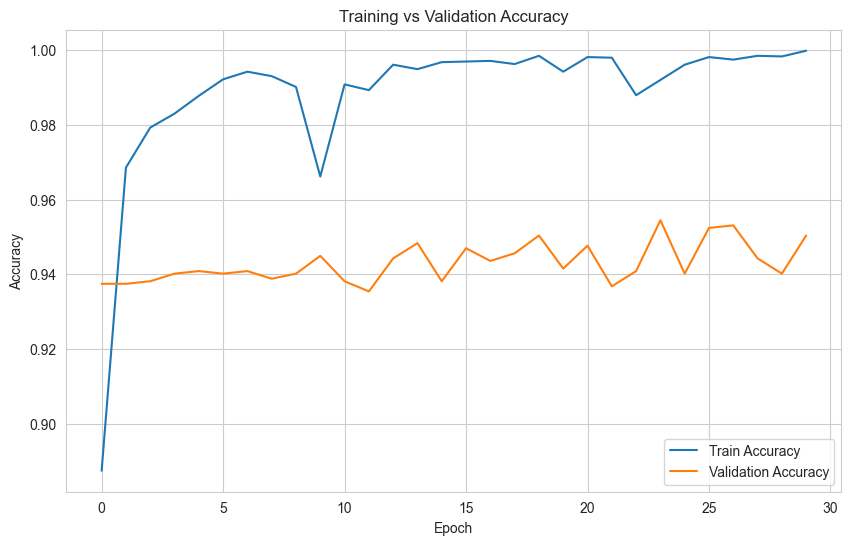

<Figure size 1200x500 with 0 Axes>

In [27]:
# TODO: Plot training accuracy vs validation accuracy over epochs
# Use best_history.history['accuracy'] and best_history.history['val_accuracy']
plt.plot(best_history.history['accuracy'], label='Train Accuracy')
plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')

if best_history is not None:
    plt.figure(figsize=(12, 5))
    
    # Your plotting code here
    
    plt.show()
else:
    print("Train best model first to visualize results")

### Visualize Training Progress - Loss

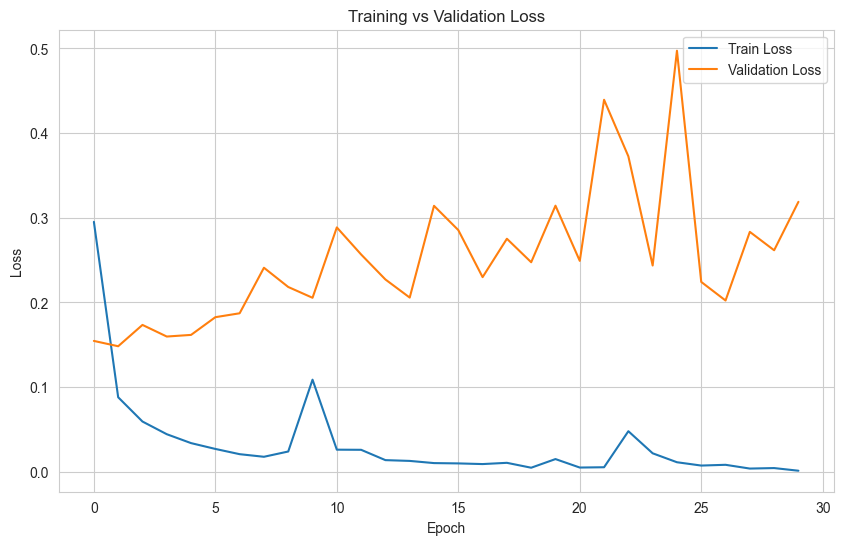

<Figure size 1200x500 with 0 Axes>

In [28]:
# TODO: Plot training loss vs validation loss over epochs
# Use best_history.history['loss'] and best_history.history['val_loss']
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
if best_history is not None:
    plt.figure(figsize=(12, 5))
    
    # Your plotting code here
    
    plt.show()
else:
    print("Train best model first to visualize results")

---
## Step 6: Compare Against Unit 7 PCA + Random Forest

In [30]:
# TODO: Enter your Unit 7 PCA+Random Forest results here
# You should have recorded these in Unit 7
unit7_pca_rf_accuracy = 0.9195792078971863  # Replace with your Unit 7 test accuracy
unit7_pca_rf_time = 11.01  # Replace with your Unit 7 training time (if you have it)

# Create comparison table
comparison = pd.DataFrame({
    'Model': [
        'Baseline NN (1 layer, 64 nodes)',
        'Best NN (Your Architecture)',
        'Unit 7: PCA + Random Forest'
    ],
    'Features/Layers': [
        '1 hidden layer',
        '3 hidden layers (128, 64, 32)',
        '30 PCA components'
    ],
    'Test Accuracy': [
        baseline_test_accuracy,
        best_test_accuracy,
        unit7_pca_rf_accuracy
    ],
    'Training Time': [
        f"{baseline_time:.2f}s" if baseline_time else 'N/A',
        f"{best_time:.2f}s" if best_time else 'N/A',
        f"{unit7_pca_rf_time:.2f}s" if unit7_pca_rf_time else 'N/A'
    ]
})

print("\n" + "="*80)
print("MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)


MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7
                          Model               Features/Layers  Test Accuracy Training Time
Baseline NN (1 layer, 64 nodes)                1 hidden layer       0.926705         4.97s
    Best NN (Your Architecture) 3 hidden layers (128, 64, 32)       0.919579        11.01s
    Unit 7: PCA + Random Forest             30 PCA components       0.919579        11.01s


### Reflection on Neural Network vs PCA+Random Forest
In the Markdown cell, write 2-3 sentences that answer the following questions:
- How does your best neural network compare to PCA+Random Forest?
- Did the neural network's ability to learn its own features from raw sensor data lead to better performance than manually engineering features with PCA? (2-3 sentences)

The baseline neural network with one hidden layer performed slightly better than both the deeper neural network and the PCA + Random Forest model because the model was about 0.9267 accurate, while the deeper neural network and the PCA + Random Forest model were both  about 0.9196. This tells us that allowing the neural network to learn features from the raw data, did not significantly outperform the PCA and a simpler neural network was able to perform slightly better with less difficulty and faster training time.

---
## Step 7: Reflect on When to Use Neural Networks

### When to Use Neural Networks vs Simpler Models

In the Markdown cell below, write 3-4 sentences addressing the following: 
- Based on your results and what you learned in the resources, when should you use neural networks versus simpler models like random forests? Consider factors like data type (sensor data, images, text vs tabular business data), dataset size, interpretability needs, and performance requirements. 
- Give at least one example of when you'd choose neural networks and one example of when you'd choose random forests

Neural networks are most useful when working with large or difficult datasets such as images, sensor data, or text where patterns may be difficult to find manually. With these types of issues, neural networks can learn features directly from the raw data and sometimes perform better than simpler models. However, simpler models like random forests can still work when working with structured data and  require less training, even if the differences between the two are not large. For example, a neural network might be useful for recognizing patterns in sensor data from wearable devices, while a random forest might more useful for predicting outcomes in structured datasets such as medical or business records.

---
## Step 8: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - Baseline neural network trained and evaluated
   - At least 3 depth experiments (1, 2, 3 layers)
   - At least 3 width experiments (32, 64, 128 nodes)
   - Best model trained for 30 epochs with accuracy and loss plots
   - Comparison table with baseline NN, best NN, and Unit 7 PCA+RF
   - All reflection questions answered (2-3 or 3-4 sentences each)
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed neural networks assignment'
git push
```

Submit your GitHub repository link on the course platform.